# Temat: Seaborn + GridSpec — dashboard analityczny restauracji
Autor: Jan Pyka

### Dane startowe

In [2]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
# Globalny motyw — raz, na początku notebooka
sns.set_theme(style='whitegrid', palette='muted')
# Dataset tips — restauracja, 244 rachunki (znany z W09)
tips = sns.load_dataset('tips')
print(f"Tips dataset: {tips.shape[0]} wierszy × {tips.shape[1]} kolumn")
print(f"Kolumny: {list(tips.columns)}")
tips.head(3)

Tips dataset: 244 wierszy × 7 kolumn
Kolumny: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


# Ćwiczenie 1: Statystyczne wykresy seaborn

### Zadanie 1.1 — Barplot z hue

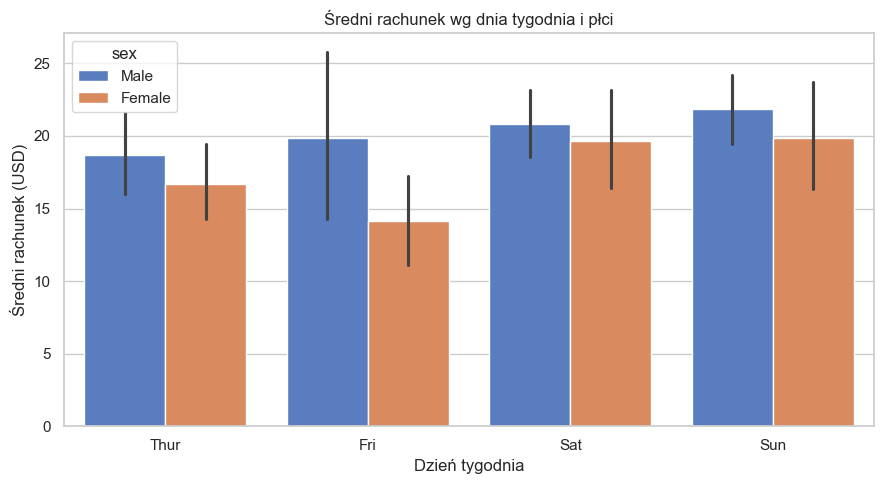

Zapisano: barplot_dzien_plec.png


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
 data=tips,
 x='day',
 y='total_bill',
 hue='sex',
 ax=ax,
 palette='muted',
 errorbar=('ci', 95), # 95% CI = przedział ufności średniej
)
ax.set_title('Średni rachunek wg dnia tygodnia i płci')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Średni rachunek (USD)')
plt.tight_layout()
plt.savefig('barplot_dzien_plec.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: barplot_dzien_plec.png")

### Zadanie 1.2 — Boxplot

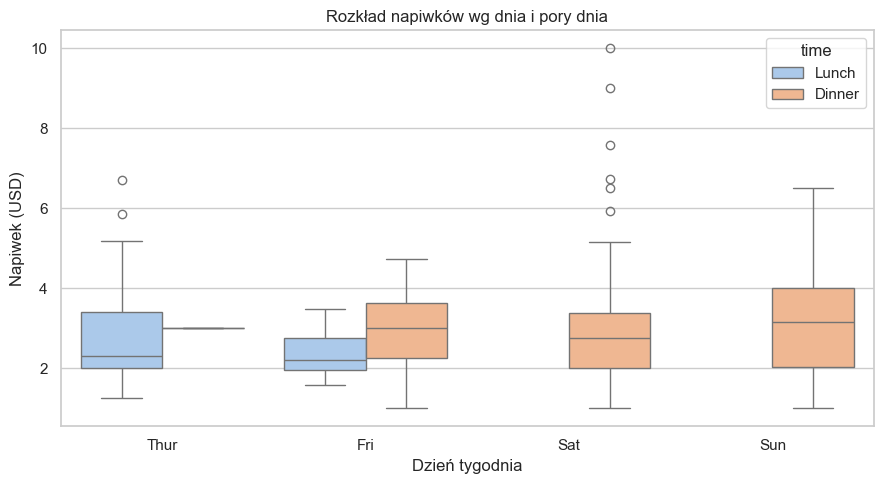

Zapisano: boxplot_napiwki.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
 data=tips,
 x=tips['day'], # kolumna kategoryczna na oś X (Thur/Fri/Sat/Sun)
 y=tips['tip'], # kolumna numeryczna na oś Y (napiwek)
 hue=tips['time'], # podział kolorystyczny (Lunch/Dinner)
 ax=ax,
 palette='pastel',
)
ax.set_title('Rozkład napiwków wg dnia i pory dnia')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Napiwek (USD)')
plt.tight_layout()
plt.savefig('boxplot_napiwki.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: boxplot_napiwki.png")

### Zadanie 1.3 — Heatmap korelacji

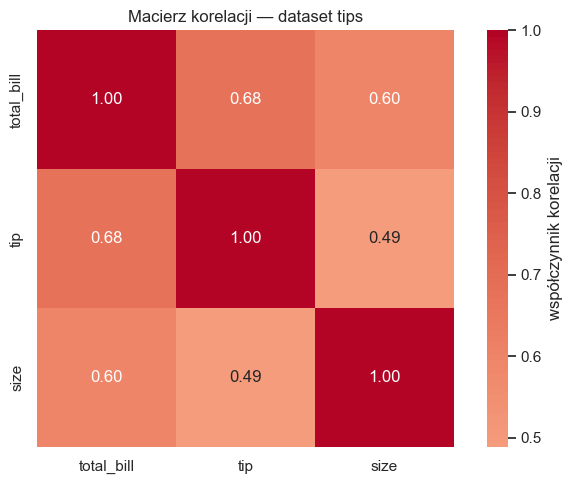

Zapisano: heatmap_korelacja.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
# Korelacja tylko zmiennych numerycznych
corr = tips.select_dtypes('number').corr()
sns.heatmap(
 corr,
 annot=True, # True — pokaż liczby w komórkach
 fmt='.2f', # 2 miejsca po przecinku
 cmap='coolwarm', # 'coolwarm' — paleta dywergencyjna (czerwony=+,niebieski=-)
 center=0, # 0 — środek skali (biały = 0 korelacja)
 ax=ax,
 square=True,
 cbar_kws={'label': 'współczynnik korelacji'},
)
ax.set_title('Macierz korelacji — dataset tips')
plt.tight_layout()
plt.savefig('heatmap_korelacja.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: heatmap_korelacja.png")


### Zadanie 1.4 — Scatter z hue + style

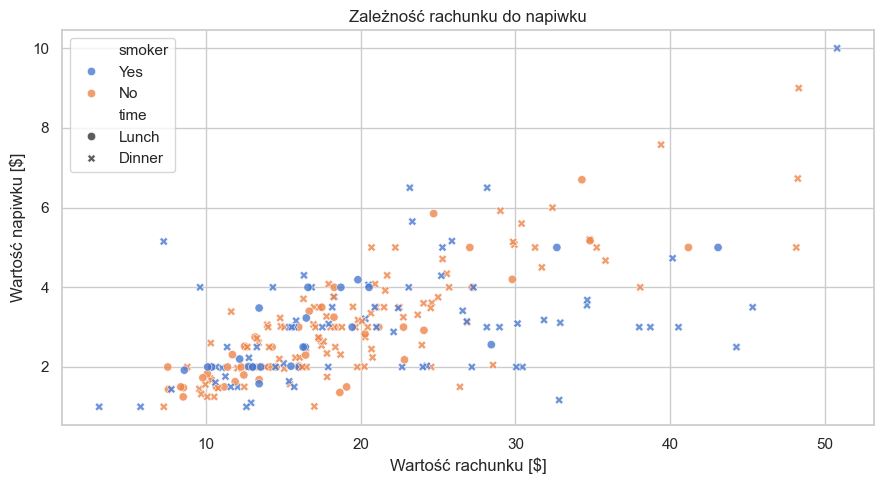

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data = tips,
    x= tips['total_bill'], 
    y= tips['tip'], 
    hue=tips['smoker'], 
    style=tips['time'], 
    alpha=0.8)
ax.set_title('Zależność rachunku do napiwku')
ax.set_xlabel('Wartość rachunku [$]')
ax.set_ylabel('Wartość napiwku [$]')
plt.tight_layout()
plt.savefig('scatter_rachunek_napiwek.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()


# Ćwiczenie 2: Subplots, GridSpec, shared axes

### Zadanie 2.1 — Regularna siatka 2×2


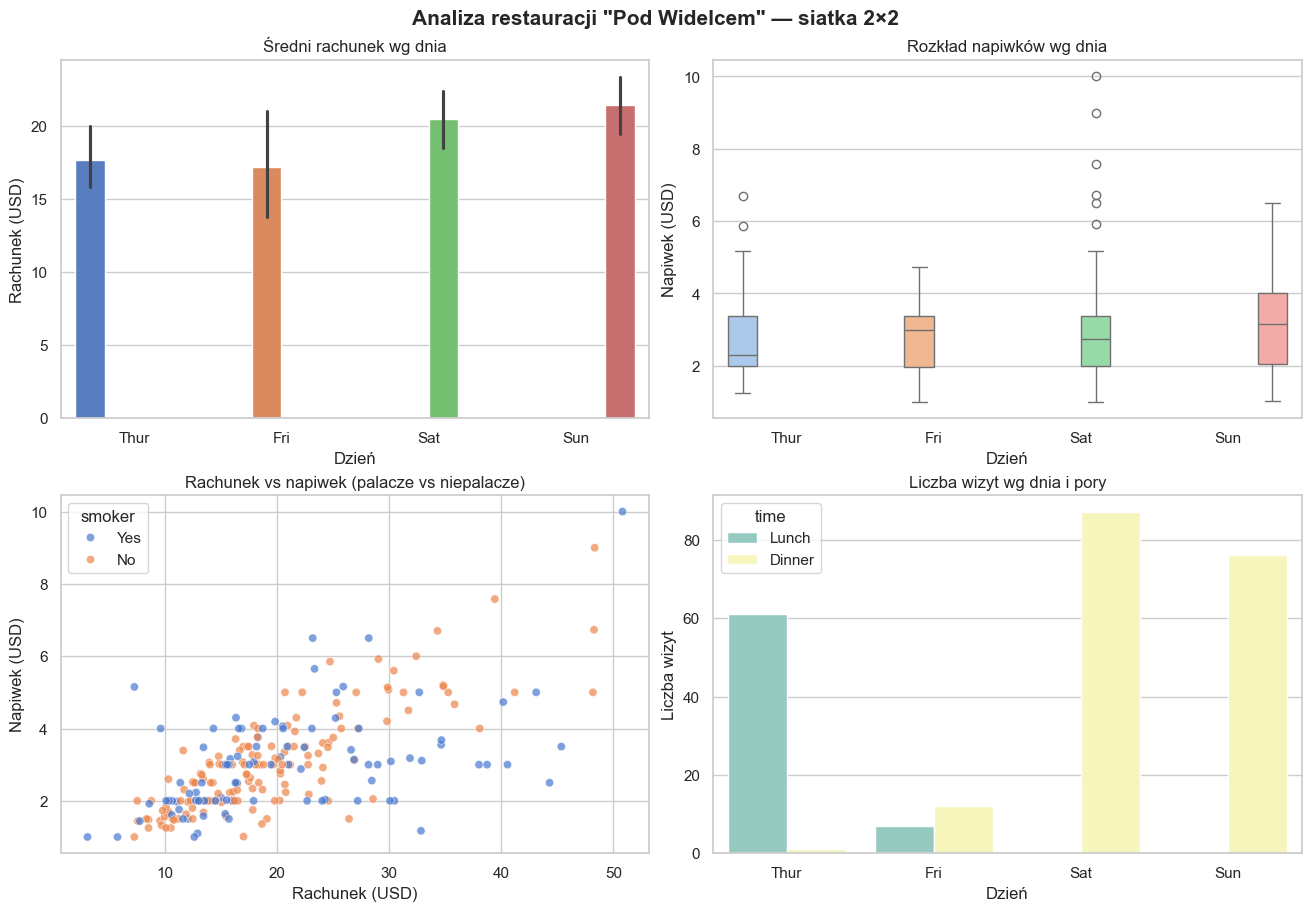

Zapisano: siatka_2x2.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
# Panel [0, 0] — barplot (gotowy wzór)
sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False,
 ax=axes[0, 0], palette='muted', errorbar=('ci',95))
axes[0, 0].set_title('Średni rachunek wg dnia')
axes[0, 0].set_xlabel('Dzień')
axes[0, 0].set_ylabel('Rachunek (USD)')
# Panel [0, 1] — boxplot (uzupełnij)
sns.boxplot(
 data=tips,
 x=tips['day'], # 'day'
 y=tips['tip'], # 'tip'
 hue='day', legend=False,
 ax=axes[0, 1],
 palette='pastel',
)
axes[0, 1].set_title('Rozkład napiwków wg dnia')
axes[0, 1].set_xlabel('Dzień')
axes[0, 1].set_ylabel('Napiwek (USD)')
# Panel [1, 0] — scatter (uzupełnij)
sns.scatterplot(
 data=tips,
 x=tips['total_bill'], # 'total_bill'
 y=tips['tip'], # 'tip'
 hue='smoker',
 alpha=0.7,
 ax=axes[1, 0],
)
axes[1, 0].set_title('Rachunek vs napiwek (palacze vs niepalacze)')
axes[1, 0].set_xlabel('Rachunek (USD)')
axes[1, 0].set_ylabel('Napiwek (USD)')
# Panel [1, 1] — countplot (uzupełnij)
sns.countplot(
 data=tips,
 x=tips['day'], # 'day'
 hue='time',
 ax=axes[1, 1],
 palette='Set3',
)
axes[1, 1].set_title('Liczba wizyt wg dnia i pory')
axes[1, 1].set_xlabel('Dzień')
axes[1, 1].set_ylabel('Liczba wizyt')
fig.suptitle('Analiza restauracji "Pod Widelcem" — siatka 2×2', fontsize=15, fontweight='bold')
plt.savefig('siatka_2x2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: siatka_2x2.png")

### Zadanie 2.2 — GridSpec — nieregularny dashboard

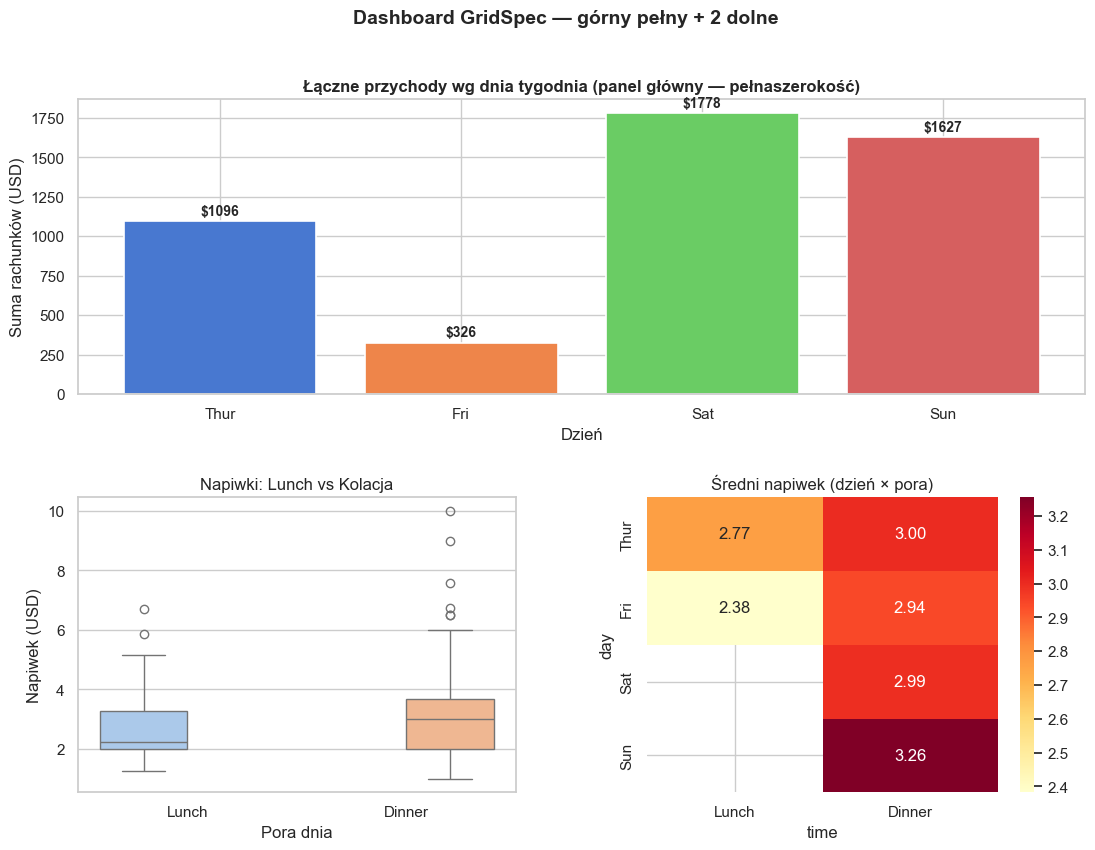

Zapisano: gridspec_dashboard.png


In [21]:
fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)
# Górny — pełna szerokość: barplot suma rachunków per dzień
ax_top = fig.add_subplot(gs[0, :])
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
ax_top.bar(
 tips_sum['day'].astype(str),
 tips_sum['total_bill'],
 color=sns.color_palette('muted')[:4],
 edgecolor='white', linewidth=1.2,
)
# Dodaj wartości nad słupkami
for i, val in enumerate(tips_sum['total_bill']):
 ax_top.text(i, val + 20, f'${val:.0f}',
 ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_top.set_title('Łączne przychody wg dnia tygodnia (panel główny — pełnaszerokość)',
 fontsize=12, fontweight='bold')
ax_top.set_xlabel('Dzień')
ax_top.set_ylabel('Suma rachunków (USD)')
# Dolny lewy — boxplot Lunch vs Dinner (uzupełnij)
ax_bl = fig.add_subplot(gs[1, 0])
sns.boxplot(
 data=tips,
 x='time', # 'time'
 y='tip', # 'tip'
 hue='time', legend=False,
 ax=ax_bl,
 palette='pastel',
)
ax_bl.set_title('Napiwki: Lunch vs Kolacja')
ax_bl.set_xlabel('Pora dnia')
ax_bl.set_ylabel('Napiwek (USD)')
# Dolny prawy — heatmap pivot (samodzielnie)
# Cel: stwórz pivot_table — wiersze=day, kolumny=time, wartości=mean(tip)
# Zwizualizuj jako heatmap z annot=True, fmt='.2f', cmap='YlOrRd'
ax_br = fig.add_subplot(gs[1, 1])
# Twój kod:
pivot = tips.pivot_table(
    values='tip',
    index='day',
    columns='time',
    aggfunc='mean'
)
sns.heatmap(
    data=pivot,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd'
)
ax_br.set_title('Średni napiwek (dzień × pora)')
fig.suptitle('Dashboard GridSpec — górny pełny + 2 dolne',
 fontsize=14, fontweight='bold')
plt.savefig('gridspec_dashboard.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: gridspec_dashboard.png")


### Zadanie 2.3 — Shared axes

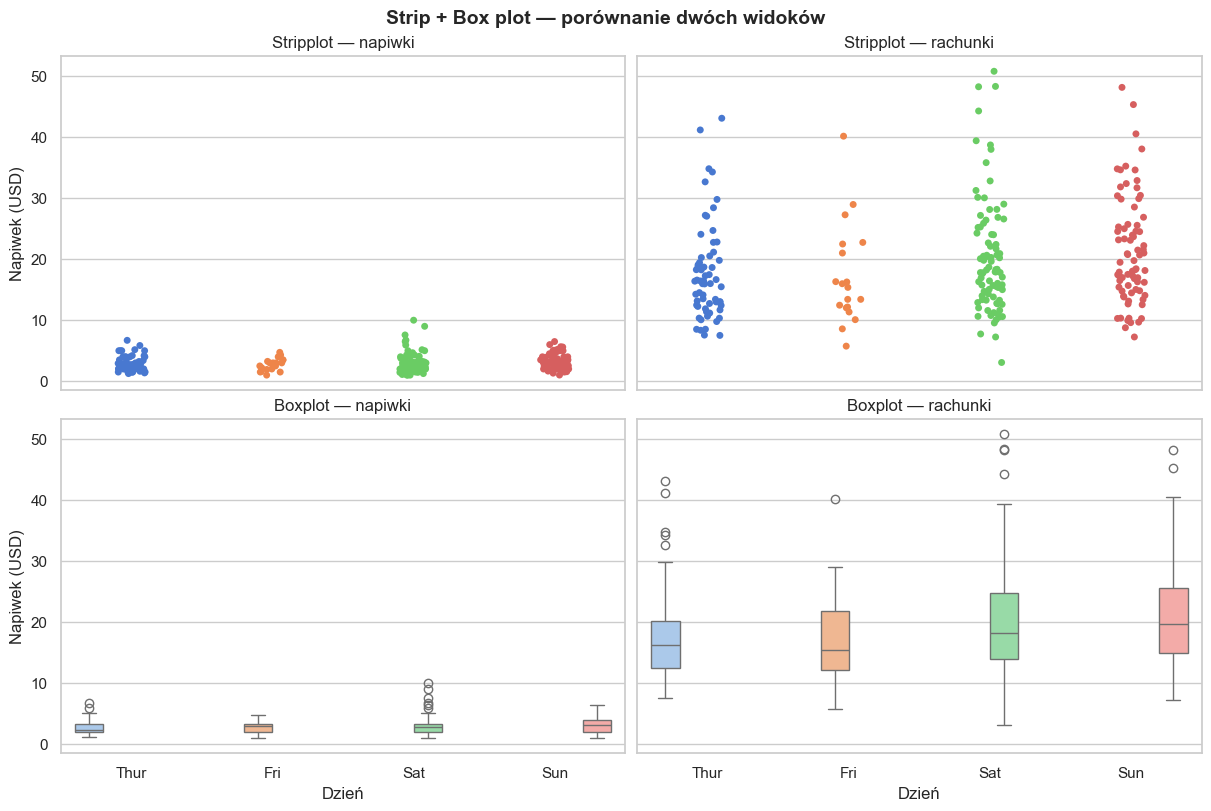

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8),
 sharex='col', sharey='row',
 constrained_layout=True)
# Twój kod — 4 wykresy

# [0, 0] — stripplot napiwki
sns.stripplot(
    data=tips,
    x='day',
    y='tip',
    ax=axes[0, 0],
    hue='day',
    legend=False,
    palette='muted'
)

axes[0, 0].set_title('Stripplot — napiwki')
axes[0, 0].set_xlabel('Dzień')
axes[0, 0].set_ylabel('Napiwek (USD)')


# [1, 0] — boxplot napiwki
sns.boxplot(
    data=tips,
    x='day',
    y='tip',
    ax=axes[1, 0],
    hue='day',
    legend=False,
    palette='pastel'
)

axes[1, 0].set_title('Boxplot — napiwki')
axes[1, 0].set_xlabel('Dzień')
axes[1, 0].set_ylabel('Napiwek (USD)')


# [0, 1] — stripplot rachunki
sns.stripplot(
    data=tips,
    x='day',
    y='total_bill',
    ax=axes[0, 1],
    hue='day',
    legend=False,
    palette='muted'
)

axes[0, 1].set_title('Stripplot — rachunki')
axes[0, 1].set_xlabel('Dzień')
axes[0, 1].set_ylabel('Rachunek (USD)')


# [1, 1] — boxplot rachunki
sns.boxplot(
    data=tips,
    x='day',
    y='total_bill',
    ax=axes[1, 1],
    hue='day',
    legend=False,
    palette='pastel'
)

axes[1, 1].set_title('Boxplot — rachunki')
axes[1, 1].set_xlabel('Dzień')
axes[1, 1].set_ylabel('Rachunek (USD)')

#axes[1, 0] boxplot napiwki
#axes[0, 1] stripplot rachunki
#axes[1, 1] boxplot rachunki
fig.suptitle('Strip + Box plot — porównanie dwóch widoków',
 fontsize=14, fontweight='bold')
plt.savefig('shared_axes.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

# Ćwiczenie 3: Pełny dashboard analityczny (30 min)

1. Pytanie główne (KPI): w którym dniu restauracja zarabia najwięcej? → 1 panel duży (górny, pełna szerokość lub 2/3)
2. 3-4 panele pomocnicze: rozkład napiwków, korelacja zmiennych, scatter rachunek↔napiwek, proporcja dni (pie/countplot)
3. 1 panel sumaryczny (dolny, pełna szerokość): rozkład rachunków per dzień (violinplot)

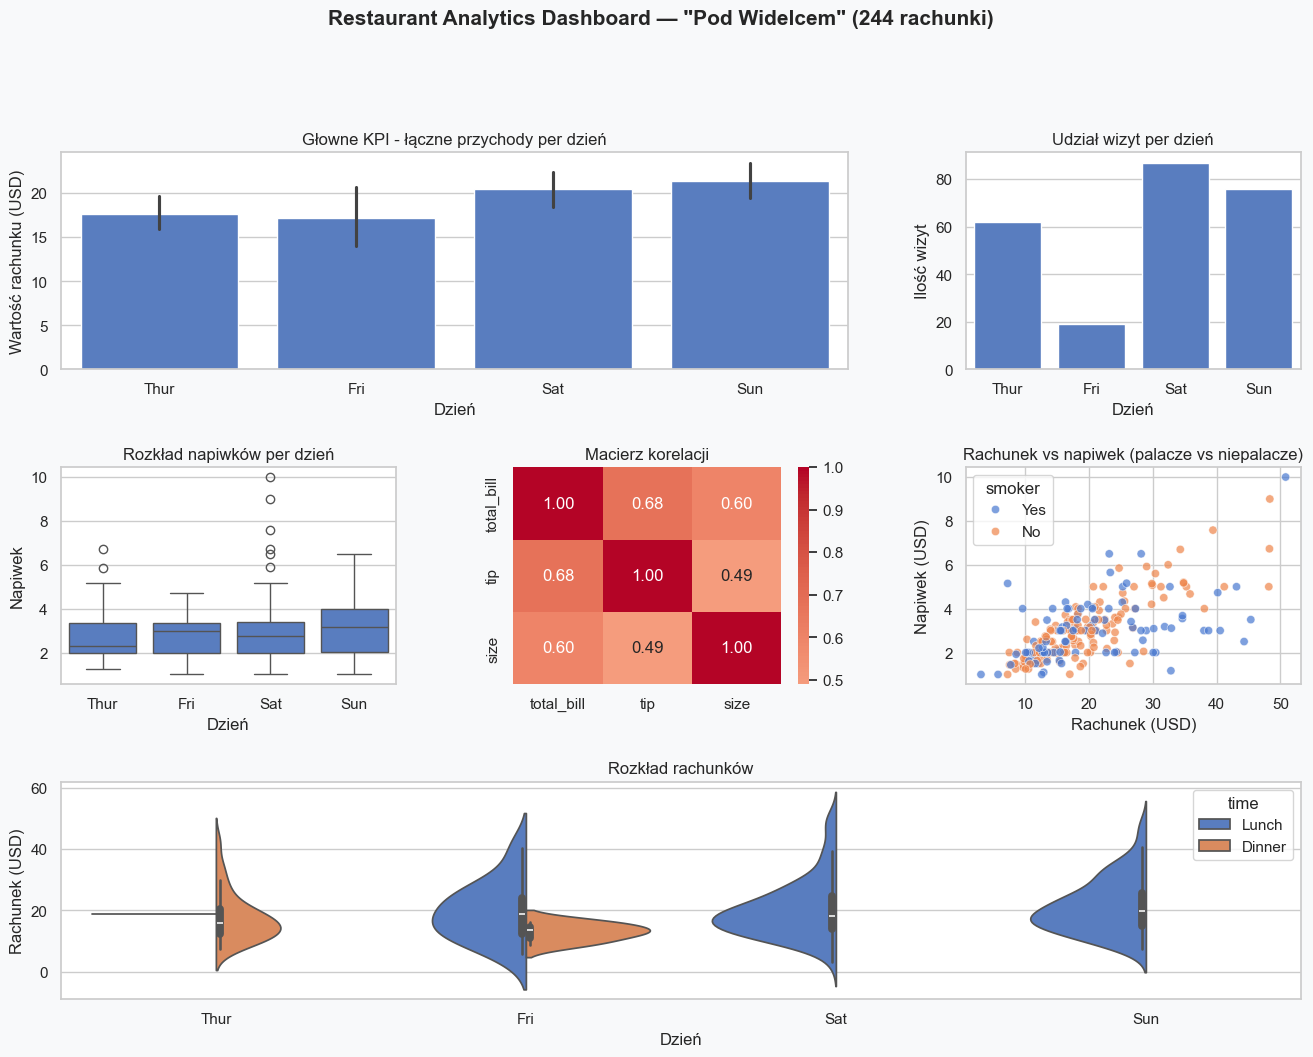

Zapisano: dashboard_pod_widelcem.png


In [15]:
# Restaurant Analytics Dashboard "Pod Widelcem"
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#f8f9fa') # tło figury — jasnoszare
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
# === PANEL 1 (KPI główny): łączne przychody per dzień (gs[0, :2]) ===
ax1 = fig.add_subplot(gs[0, :2])
sns.barplot(
    data = tips,
    x = 'day',
    y = 'total_bill',
    ax = ax1
)
ax1.set_title('Głowne KPI - łączne przychody per dzień')
ax1.set_xlabel('Dzień')
ax1.set_ylabel('Wartość rachunku (USD)')
# Twój kod — barplot z etykietami wartości nad słupkami
# === PANEL 2: udział wizyt per dzień (gs[0, 2]) ===
ax2 = fig.add_subplot(gs[0, 2])
sns.countplot(
    data=tips,
    x='day',
    ax=ax2
)
ax2.set_title('Udział wizyt per dzień')
ax2.set_ylabel('Ilość wizyt')
ax2.set_xlabel('Dzień')
# Twój kod — pie chart lub countplot
# === PANEL 3: rozkład napiwków (gs[1, 0]) ===
ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(
    data=tips,
    x='day',
    y='tip',
    ax=ax3
)
ax3.set_title('Rozkład napiwków per dzień')
ax3.set_xlabel('Dzień')
ax3.set_ylabel('Napiwek')
# Twój kod — boxplot napiwki per dzień
# === PANEL 4: heatmap korelacji (gs[1, 1]) ===
ax4 = fig.add_subplot(gs[1, 1])
corr = tips.select_dtypes('number').corr()
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
ax4.set_title('Macierz korelacji')
# Twój kod — sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
# === PANEL 5: scatter (gs[1, 2]) ===
ax5 = fig.add_subplot(gs[1, 2])
sns.scatterplot(
 data=tips,
 x=tips['total_bill'], # 'total_bill'
 y=tips['tip'], # 'tip'
 hue='smoker',
 alpha=0.7,
 ax=ax5,
)
ax5.set_title('Rachunek vs napiwek (palacze vs niepalacze)')
ax5.set_xlabel('Rachunek (USD)')
ax5.set_ylabel('Napiwek (USD)')
# Twój kod — sns.scatterplot rachunek vs napiwek z hue='smoker'
# === PANEL 6 (sumaryczny): rozkład rachunków (gs[2, :]) ===
ax6 = fig.add_subplot(gs[2, :])
sns.violinplot(
    data=tips,
    x=tips['day'],
    y=tips['total_bill'],
    hue='time',
    split=True
)
ax6.set_title('Rozkład rachunków')
ax6.set_xlabel('Dzień')
ax6.set_ylabel('Rachunek (USD)')
# Twój kod — sns.violinplot rachunki per dzień z hue='time', split=True
fig.suptitle('Restaurant Analytics Dashboard — "Pod Widelcem" (244 rachunki)',
 fontsize=15, fontweight='bold', y=1.01)
plt.savefig('dashboard_pod_widelcem.png',
 dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: dashboard_pod_widelcem.png")


### Zadanie 3.3 — Wnioski biznesowe

Najbardziej dochodowym dniem dla restauracji jest Sobota. Istnieje korelacja między rachunkiem a napiwkiem - 0.68 - jest ona silna. Większość napiwków zostawianych przez palaczy jak i niepalaczy jest na podobnym poziomie. Sobota i niedziela są dniami o największej ilości klientów (lunch) dlatego warto dostosować ilość obsługujących pracowników, aby nie było opóźnień. Wraz z ceną zamówienia zwiększa się także wysokość napiwku, dlatego warto proponować klientom domawianie dodatkowych pozycji z menu.

# Ćwiczenie 4: Style, eksport, adnotacja, commit

### Zadanie 4.1 — Porównanie stylów seaborn

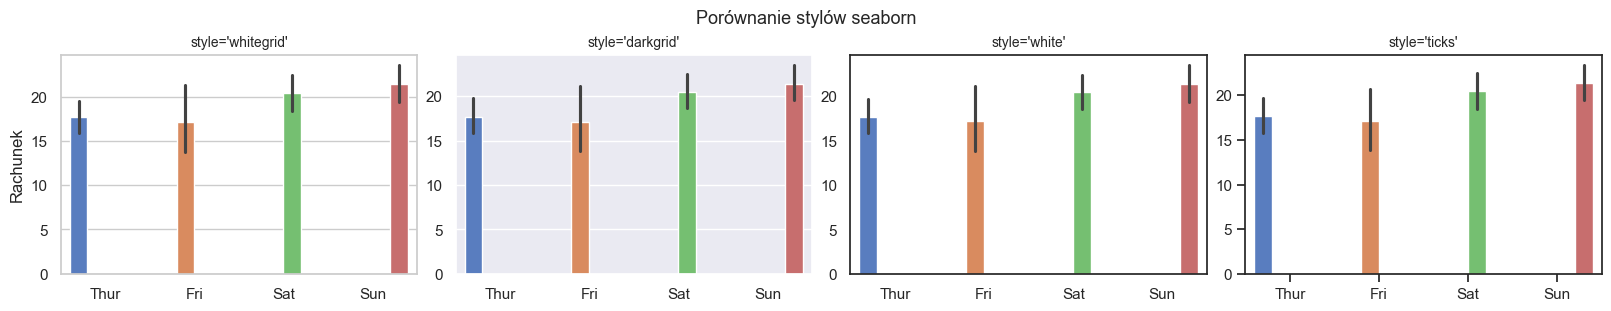

In [21]:
styles = ['whitegrid', 'darkgrid', 'white', 'ticks']

fig = plt.figure(figsize=(16, 3), constrained_layout=True)

for i, style in enumerate(styles, 1):

    with sns.axes_style(style):

        ax = fig.add_subplot(1, 4, i)

        sns.barplot(
            data=tips,
            x='day',
            y='total_bill',
            hue='day',
            legend=False,
            ax=ax,
            palette='muted'
        )

        ax.set_title(f"style='{style}'", fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Rachunek' if i == 1 else '')

fig.suptitle('Porównanie stylów seaborn', fontsize=13)

plt.savefig(
    'porownanie_stylow.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()

Podany w treści zadania kod utworzył 4 identyczne wykresy, dlatego wspomogłem się AI, aby uzyskać wymagany wynik. Do prezentacji użyłbym stylu whitegrid, ze względu na jego przejrzystość, a do pracy drukowanej - stylu ticks, ponieważ posiada on ciemną ramkę zewnętrzną, co powoduje, że przy druku ramka ta będzie widoczna, nawet jeśli wystąpią jakiekolwiek problemy - styl whitegrid mógłby być niewidoczny na jasnej kartce.

### Zadanie 4.2 — Adnotacja na wykresie

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
sns.barplot(data=tips_sum, x='day', y='total_bill', hue='day', legend=False,
 ax=ax, palette='muted')
# Znajdź szczyt
max_idx = tips_sum['total_bill'].idxmax()
max_day = tips_sum.loc[max_idx, 'day']
max_val = tips_sum.loc[max_idx, 'total_bill']
# Adnotacja ze strzałką
ax.annotate(
 f'Szczyt: ${max_val:.0f} ({max_day})',
 xy=(max_idx, max_val), # punkt na który wskazuje strzałka — (max_idx,max_val)
 xytext=(max_idx + 0.5, max_val + 200), # gdzie tekst — (max_idx + 0.5, max_val + 200)
 arrowprops=dict(arrowstyle='->', color='red', lw=1.8),
 fontsize=11, color='red', fontweight='bold',
)
# Tytuł celowo pominięty — adnotacja 'Szczyt: $...' sama w sobie informuje o czym wykres
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Suma rachunków (USD)')
sns.despine() # usuwa górną i prawą krawędź osi(minimalistyczny styl)
plt.tight_layout()
plt.savefig('szczyt_przychodow.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: szczyt_przychodow.png")


SyntaxError: unmatched ')' (712562141.py, line 17)